# Analyze JobB — trained-models validation on Deceuninck

Companion to `analyze jobA.ipynb`, but focused on the **JobB** runs that re-evaluate the trained
models against the Deceuninck dataset.

The single Deceuninck category means we cannot compute per-category statistics the way JobA does —
instead we treat each model run as one observation and dig into the per-image score distribution
and the per-defect-type recall to understand model behavior.

Sections:
1. **Setup** — paths, imports.
2. **Loader** — walks `data/outputs/jobB_val_defect_V1/` and returns a tidy DataFrame.
3. **§1 Summary metrics per model** — single comparison table, plus a `per_defect_recall` view.
4. **§2 Graphical comparison** — accuracy bars, latency-vs-quality Pareto, generalization gap.
5. **§3 Coherence / sanity checks** — flags `0.0` / `1.0` metrics, threshold position relative to
   the actual score distribution, sample-count vs fit-time consistency.
6. **§4 Score distributions** — per-model histogram of test scores split by `good` vs `defect`
   with the calibrated threshold drawn on top.
7. **§5 Confusion matrices** — derived from `predictions_*.json` so the headline F1 can be audited.
8. **§6 JobB vs JobA reference** — quick reuse of `_analysis/compare_jobB_vs_jobA.tsv`.
9. **§7 Engineering suggestions** — what to look at next, framed for the thesis goal.

## 1. Setup

In [1]:
from __future__ import annotations

import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO = Path.cwd().resolve()
if REPO.name == "notebooks":
    REPO = REPO.parent

OUTPUTS = REPO / "data" / "outputs"
JOBB_DIR = OUTPUTS / "jobB_val_defect_V1"
JOBA_DIR = OUTPUTS / "jobA_val_defect_V1"
ANALYSIS_DIR = JOBB_DIR / "_analysis"

assert JOBB_DIR.is_dir(), f"missing {JOBB_DIR}"
print("REPO    :", REPO)
print("JOBB    :", JOBB_DIR)
print("JOBA    :", JOBA_DIR if JOBA_DIR.is_dir() else "(not present)")

REPO    : C:\Users\Usuario\Desktop\Thesis\Pipeline\Real-time-visual-defect-detection
JOBB    : C:\Users\Usuario\Desktop\Thesis\Pipeline\Real-time-visual-defect-detection\data\outputs\jobB_val_defect_V1
JOBA    : C:\Users\Usuario\Desktop\Thesis\Pipeline\Real-time-visual-defect-detection\data\outputs\jobA_val_defect_V1


## 2. Loader

Each JobB run directory holds a `benchmark_summary.json` whose `models[]` array contains one entry
per model that ran. Some directories bundle 3 models (the Deceuninck mass-eval), others contain a
single model — we just iterate and flatten.

Per-image scores are taken from `predictions_<model>.json` and `validation_predictions_<model>.json`.

In [2]:
def load_jobB_runs(directory: Path) -> pd.DataFrame:
    rows = []
    for run_dir in sorted(p for p in directory.iterdir() if p.is_dir() and not p.name.startswith("_")):
        summary_path = run_dir / "benchmark_summary.json"
        if not summary_path.is_file():
            continue
        b = json.loads(summary_path.read_text())
        run_meta = {
            "run_dir": run_dir.name,
            "run_id": b.get("run", {}).get("run_id"),
            "corruption_enabled": b.get("corruption", {}).get("enabled"),
            "corruption_type": b.get("corruption", {}).get("type"),
            "corruption_severity": b.get("corruption", {}).get("severity"),
            "dataset_path": b.get("dataset", {}).get("path"),
            "resize_w": b.get("preprocessing", {}).get("resize", {}).get("width"),
            "resize_h": b.get("preprocessing", {}).get("resize", {}).get("height"),
        }
        for m in b.get("models", []):
            row = {**run_meta}
            row.update({k: v for k, v in m.items() if k not in {"model_cfg", "per_defect_recall", "per_defect_support"}})
            row["per_defect_recall"] = m.get("per_defect_recall", {})
            row["per_defect_support"] = m.get("per_defect_support", {})
            rows.append(row)
    return pd.DataFrame(rows)


def load_predictions(run_dir: Path, model: str, validation: bool = False) -> pd.DataFrame:
    fname = ("validation_predictions_" if validation else "predictions_") + f"{model}.json"
    path = run_dir / fname
    if not path.is_file():
        return pd.DataFrame()
    return pd.DataFrame(json.loads(path.read_text()))


df = load_jobB_runs(JOBB_DIR)
print(f"Loaded {len(df)} model rows from {df['run_dir'].nunique()} run directories.")
df[["run_dir", "model", "train_samples", "val_samples", "test_samples", "corruption_enabled"]]

Loaded 6 model rows from 4 run directories.


,run_dir,model,train_samples,val_samples,test_samples,corruption_enabled
0,jobB_anomalib_draem_20260428_085806,anomalib_draem,161,67,478,False
1,jobB_anomalib_stfpm_20260427_231116,anomalib_stfpm,161,67,478,False
2,jobB_rd4ad_20260428_072729,rd4ad,161,67,478,False
3,jobB_val_defect_deceuninck_20260427_102501,anomalib_patchcore,161,67,478,False
4,jobB_val_defect_deceuninck_20260427_102501,anomalib_padim,161,67,478,False
5,jobB_val_defect_deceuninck_20260427_102501,subspacead,161,67,478,False


## §1 Summary metrics per model

Headline numbers, one row per model. The `_industrial` block (recall@1pct FPR / recall@5pct FPR /
macro_recall) is the metric set the thesis uses for the rolling-window industrial benchmark.

In [3]:
headline_cols = [
    "model",
    "train_samples", "val_samples", "test_samples",
    "auroc", "aupr", "f1", "precision", "recall", "accuracy",
    "recall_at_fpr_1pct", "recall_at_fpr_5pct", "macro_recall", "weighted_recall",
    "threshold_mode", "threshold_used",
    "fit_seconds", "predict_seconds", "ms_per_image", "fps", "peak_vram_mb",
]
summary = df[headline_cols].copy()
summary = summary.sort_values("f1", ascending=False).reset_index(drop=True)
summary.round(4)

,model,train_samples,val_samples,test_samples,auroc,aupr,f1,precision,recall,accuracy,...,recall_at_fpr_5pct,macro_recall,weighted_recall,threshold_mode,threshold_used,fit_seconds,predict_seconds,ms_per_image,fps,peak_vram_mb
0,anomalib_patchcore,161,67,478,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,...,1.0000,1.0000,1.0000,val_f1,37.6074,762.7088,159.7645,334.2353,2.9919,12430.021
1,subspacead,161,67,478,1.0000,1.0000,0.9988,1.0000,0.9977,0.9979,...,1.0000,0.9994,0.9977,val_f1,6.6127,137.9544,178.9901,374.4562,2.6705,1918.379
2,anomalib_padim,161,67,478,0.9999,1.0000,0.9977,1.0000,0.9954,0.9958,...,1.0000,0.9770,0.9954,val_f1,70.0831,11.6471,9.6683,20.2265,49.4400,4202.877
3,rd4ad,161,67,478,1.0000,1.0000,0.9824,1.0000,0.9654,0.9686,...,1.0000,0.9915,0.9654,val_f1,0.0020,1987.7145,12.1509,25.4204,39.3386,19563.863
4,anomalib_draem,161,67,478,0.8016,0.9705,0.9653,0.9370,0.9954,0.9351,...,0.3210,0.9989,0.9954,val_f1,0.9896,2861.0278,17.9171,37.4835,26.6784,79980.318
5,anomalib_stfpm,161,67,478,0.8923,0.9874,0.9080,0.9686,0.8545,0.8431,...,0.6397,0.9373,0.8545,val_f1,0.0192,446.4042,6.6905,13.9968,71.4449,3111.561


In [4]:
# val (calibration) vs test (held-out) — generalization gap.
gap_cols = ["model", "val_f1", "f1", "val_auroc", "auroc", "val_aupr", "aupr", "val_recall", "recall", "val_precision", "precision"]
gap = df[gap_cols].copy()
for m in ["f1", "auroc", "aupr", "recall", "precision"]:
    gap[f"{m}_gap"] = gap[m] - gap[f"val_{m}"]
gap.set_index("model").round(4)

,val_f1,f1,val_auroc,auroc,val_aupr,aupr,val_recall,recall,val_precision,precision,f1_gap,auroc_gap,aupr_gap,recall_gap,precision_gap
model,,,,,,,,,,,,,,,
anomalib_draem,0.8991,0.9653,0.8707,0.8016,0.9476,0.9705,1.000,0.9954,0.8167,0.9370,0.0662,-0.0691,0.0229,-0.0046,0.1203
anomalib_stfpm,0.9072,0.9080,0.9206,0.8923,0.9715,0.9874,0.898,0.8545,0.9167,0.9686,0.0008,-0.0283,0.0159,-0.0435,0.0519
rd4ad,1.0000,0.9824,1.0000,1.0000,1.0000,1.0000,1.000,0.9654,1.0000,1.0000,-0.0176,0.0000,0.0000,-0.0346,0.0000
anomalib_patchcore,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.000,1.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000
anomalib_padim,1.0000,0.9977,1.0000,0.9999,1.0000,1.0000,1.000,0.9954,1.0000,1.0000,-0.0023,-0.0001,-0.0000,-0.0046,0.0000
subspacead,1.0000,0.9988,1.0000,1.0000,1.0000,1.0000,1.000,0.9977,1.0000,1.0000,-0.0012,0.0000,0.0000,-0.0023,0.0000


In [5]:
# Per-defect-type recall — single-row-per-model view.
all_defects = sorted({d for r in df["per_defect_recall"] for d in r})
rows = []
for _, r in df.iterrows():
    rec = {"model": r["model"]}
    for d in all_defects:
        rec[d] = r["per_defect_recall"].get(d, np.nan)
    rows.append(rec)
per_defect_df = pd.DataFrame(rows).set_index("model").round(4)
per_defect_df

,Black spots,Cleaning felt,Degassing,Pigment spill,Scratch in extrusion direction
model,,,,,
anomalib_draem,1.0000,1.0000,1.0,1.0000,0.9943
anomalib_stfpm,1.0000,0.9091,1.0,0.9474,0.8300
rd4ad,1.0000,1.0000,1.0,1.0000,0.9575
anomalib_patchcore,1.0000,1.0000,1.0,1.0000,1.0000
anomalib_padim,0.9375,1.0000,1.0,0.9474,1.0000
subspacead,1.0000,1.0000,1.0,1.0000,0.9972


In [6]:
# Per-defect support — same for every model in JobB (single dataset), so we show it once.
support = next(iter(df["per_defect_support"]), {})
support_df = pd.DataFrame({"defect": list(support), "n_test_samples": list(support.values())}).sort_values("n_test_samples", ascending=False)
support_df

,defect,n_test_samples
0,Scratch in extrusion direction,353
1,Degassing,23
3,Cleaning felt,22
4,Pigment spill,19
2,Black spots,16


## §2 Graphical comparison

Three views: a metric grid, a latency-vs-F1 Pareto, and the val→test generalization gap.

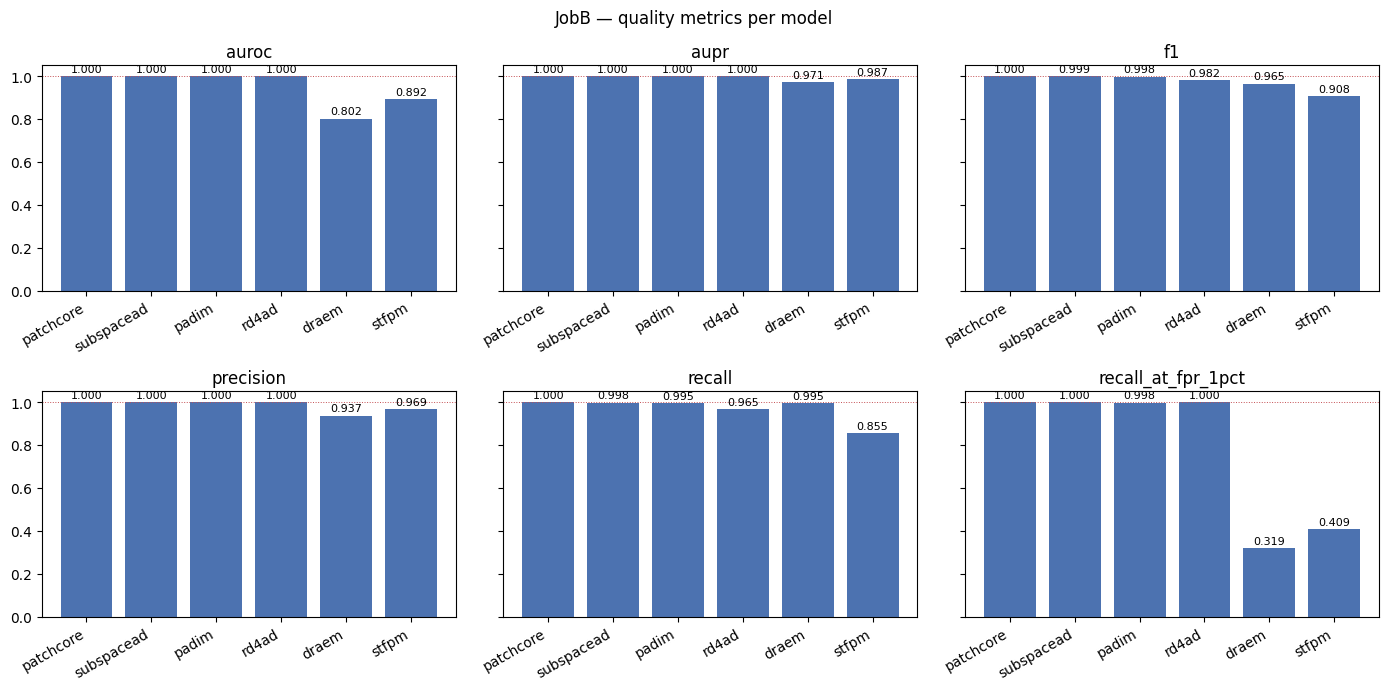

In [7]:
metrics = ["auroc", "aupr", "f1", "precision", "recall", "recall_at_fpr_1pct"]
fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharey=True)
order = df.sort_values("f1", ascending=False)["model"].tolist()
for ax, metric in zip(axes.ravel(), metrics):
    sub = df.set_index("model").loc[order, metric]
    bars = ax.bar(range(len(sub)), sub.values, color="#4C72B0")
    ax.set_xticks(range(len(sub)))
    ax.set_xticklabels([m.replace("anomalib_", "") for m in sub.index], rotation=30, ha="right")
    ax.set_title(metric)
    ax.set_ylim(0, 1.05)
    ax.axhline(1.0, color="#c44e52", lw=0.7, ls=":")
    for b, v in zip(bars, sub.values):
        ax.text(b.get_x() + b.get_width() / 2, v + 0.01, f"{v:.3f}", ha="center", va="bottom", fontsize=8)
fig.suptitle("JobB — quality metrics per model", fontsize=12)
fig.tight_layout()
plt.show()

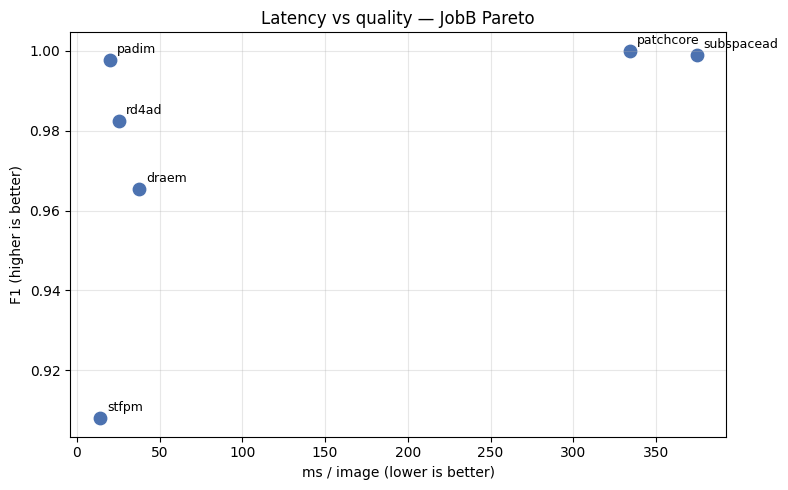

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df["ms_per_image"], df["f1"], s=80, color="#4C72B0")
for _, r in df.iterrows():
    ax.annotate(r["model"].replace("anomalib_", ""),
                (r["ms_per_image"], r["f1"]),
                xytext=(5, 5), textcoords="offset points", fontsize=9)
ax.set_xlabel("ms / image (lower is better)")
ax.set_ylabel("F1 (higher is better)")
ax.set_title("Latency vs quality — JobB Pareto")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

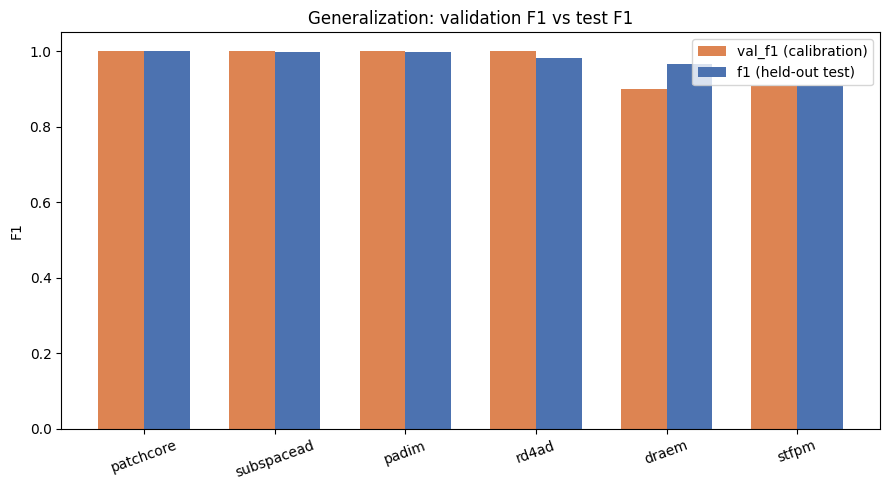

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(order))
w = 0.35
vals_val = df.set_index("model").loc[order, "val_f1"].values
vals_test = df.set_index("model").loc[order, "f1"].values
ax.bar(x - w/2, vals_val, w, label="val_f1 (calibration)", color="#dd8452")
ax.bar(x + w/2, vals_test, w, label="f1 (held-out test)", color="#4C72B0")
ax.set_xticks(x)
ax.set_xticklabels([m.replace("anomalib_", "") for m in order], rotation=20)
ax.set_ylim(0, 1.05)
ax.set_ylabel("F1")
ax.set_title("Generalization: validation F1 vs test F1")
ax.legend()
plt.tight_layout()
plt.show()

## §3 Coherence / sanity checks

Goal: surface anything that *should* be a decimal but landed exactly on `0.0` or `1.0`, plus a few
consistency checks between reported numbers and the underlying samples.

Why it matters: with only 478 test images, a single small bug (e.g. all scores collapsing to one
value, or threshold falling outside the score range) can produce "perfect" metrics that do not
reflect real performance.

In [10]:
# 3.1 — flag suspiciously round metric values
watch = ["auroc", "aupr", "f1", "precision", "recall",
         "val_auroc", "val_f1", "val_precision", "val_recall",
         "recall_at_fpr_1pct", "recall_at_fpr_5pct",
         "macro_recall", "weighted_recall", "accuracy"]
flags = []
EPS = 1e-9
for _, r in df.iterrows():
    for col in watch:
        v = r.get(col)
        if v is None or pd.isna(v):
            continue
        if abs(v - 1.0) < EPS:
            flags.append({"model": r["model"], "metric": col, "value": v, "note": "== 1.0 exactly"})
        elif abs(v) < EPS:
            flags.append({"model": r["model"], "metric": col, "value": v, "note": "== 0.0 exactly"})
        elif v > 0.9999 and v < 1.0:
            flags.append({"model": r["model"], "metric": col, "value": v, "note": "> 0.9999 (effectively saturated)"})
flag_df = pd.DataFrame(flags)
if flag_df.empty:
    print("No saturated metrics — all values are intermediate decimals.")
else:
    print(f"{len(flag_df)} saturated metric values:")
    display(flag_df.sort_values(["model", "metric"]).reset_index(drop=True))

41 saturated metric values:


,model,metric,value,note
0,anomalib_draem,val_recall,1.000000,== 1.0 exactly
1,anomalib_padim,aupr,0.999995,> 0.9999 (effectively saturated)
2,anomalib_padim,auroc,0.999949,> 0.9999 (effectively saturated)
3,anomalib_padim,precision,1.000000,== 1.0 exactly
4,anomalib_padim,recall_at_fpr_5pct,1.000000,== 1.0 exactly
5,anomalib_padim,val_auroc,1.000000,== 1.0 exactly
6,anomalib_padim,val_f1,1.000000,== 1.0 exactly
7,anomalib_padim,val_precision,1.000000,== 1.0 exactly
8,anomalib_padim,val_recall,1.000000,== 1.0 exactly
9,anomalib_patchcore,accuracy,1.000000,== 1.0 exactly


In [11]:
# 3.2 — sample-count and time consistency.
# train_samples + val_samples + test_samples should match across models on the SAME dataset run.
consistency = df.groupby("dataset_path")[["train_samples", "val_samples", "test_samples"]].agg(["min", "max"])
consistency

train_samples      val_samples      \
                                                   min  max         min max   
dataset_path                                                                  
/content/work/jobB_trained_deceuninck              161  161          67  67   
/content/work/jobB_val_defect_deceuninck           161  161          67  67   

                                         test_samples       
                                                  min  max  
dataset_path                                                
/content/work/jobB_trained_deceuninck             478  478  
/content/work/jobB_val_defect_deceuninck          478  478

In [12]:
# 3.3 — does the calibrated threshold sit inside the actual score range on val and test?
rows = []
for _, r in df.iterrows():
    run_dir = JOBB_DIR / r["run_dir"]
    test = load_predictions(run_dir, r["model"], validation=False)
    val = load_predictions(run_dir, r["model"], validation=True)
    if test.empty:
        continue
    rows.append({
        "model": r["model"],
        "threshold": r["threshold_used"],
        "val_score_min": val["score"].min() if not val.empty else None,
        "val_score_max": val["score"].max() if not val.empty else None,
        "val_score_unique": val["score"].nunique() if not val.empty else None,
        "test_score_min": test["score"].min(),
        "test_score_median": test["score"].median(),
        "test_score_max": test["score"].max(),
        "test_score_unique": test["score"].nunique(),
        "frac_test_above_thr": (test["score"] > r["threshold_used"]).mean(),
    })
score_range = pd.DataFrame(rows).set_index("model").round(6)
score_range

,threshold,val_score_min,val_score_max,val_score_unique,test_score_min,test_score_median,test_score_max,test_score_unique,frac_test_above_thr
model,,,,,,,,,
anomalib_draem,0.989597,0.989418,0.999999,61,0.989313,0.990083,1.000000,383,0.962343
anomalib_stfpm,0.019215,0.018393,0.046031,67,0.018425,0.019837,0.065060,478,0.799163
rd4ad,0.002050,0.000056,0.022906,67,0.000047,0.002971,0.024883,478,0.874477
anomalib_patchcore,37.607372,18.098227,63.422756,67,17.687716,42.227772,65.789200,478,0.905858
anomalib_padim,70.083054,12.526299,180.340836,67,12.099661,101.783691,204.740967,478,0.901674
subspacead,6.612747,2.441701,23.611210,67,2.260501,7.688532,23.525043,478,0.903766


In [13]:
# 3.4 — class balance per model (should be identical, since same split).
rows = []
for _, r in df.iterrows():
    test = load_predictions(JOBB_DIR / r["run_dir"], r["model"])
    if test.empty:
        continue
    rows.append({
        "model": r["model"],
        "n_test": len(test),
        "n_good": int((test["label"] == 0).sum()),
        "n_defect": int((test["label"] == 1).sum()),
        "defect_rate": float((test["label"] == 1).mean()),
    })
pd.DataFrame(rows).set_index("model")

,n_test,n_good,n_defect,defect_rate
model,,,,
anomalib_draem,478,45,433,0.905858
anomalib_stfpm,478,45,433,0.905858
rd4ad,478,45,433,0.905858
anomalib_patchcore,478,45,433,0.905858
anomalib_padim,478,45,433,0.905858
subspacead,478,45,433,0.905858


In [14]:
# 3.5 — fit-time vs sample-count plausibility.
df.assign(seconds_per_train_sample=df["fit_seconds"] / df["train_samples"]) \
  [["model", "train_samples", "fit_seconds", "predict_seconds", "ms_per_image"]] \
  .assign(seconds_per_train_sample=lambda x: x["fit_seconds"] / x["train_samples"]) \
  .round(2) \
  .sort_values("fit_seconds", ascending=False)

,model,train_samples,fit_seconds,predict_seconds,ms_per_image,seconds_per_train_sample
0,anomalib_draem,161,2861.03,17.92,37.48,17.77
2,rd4ad,161,1987.71,12.15,25.42,12.35
3,anomalib_patchcore,161,762.71,159.76,334.24,4.74
1,anomalib_stfpm,161,446.40,6.69,14.00,2.77
5,subspacead,161,137.95,178.99,374.46,0.86
4,anomalib_padim,161,11.65,9.67,20.23,0.07


**How to read §3:**

- A `1.0000` AUROC on 478 images is not impossible but it should always be cross-checked against
  the score histogram in §4 — perfect separability looks like two non-overlapping clusters.
- A threshold that sits *outside* the validation score range, or where `frac_test_above_thr` is
  close to `0` or `1`, means the calibration step was effectively a no-op (everything ends up
  predicted as one class).
- `test_score_unique` close to `1–2` is a hard fail: scores collapsed and the model is constant.
- For the seconds-per-sample column, models with comparable architectures should land in the same
  order of magnitude; an outlier signals a config drift between runs.

## §4 Score distributions

One subplot per model, log-scale y to make the rare-class tail visible. Vertical line is the
calibrated threshold; bars to its right are predicted as *anomaly*.

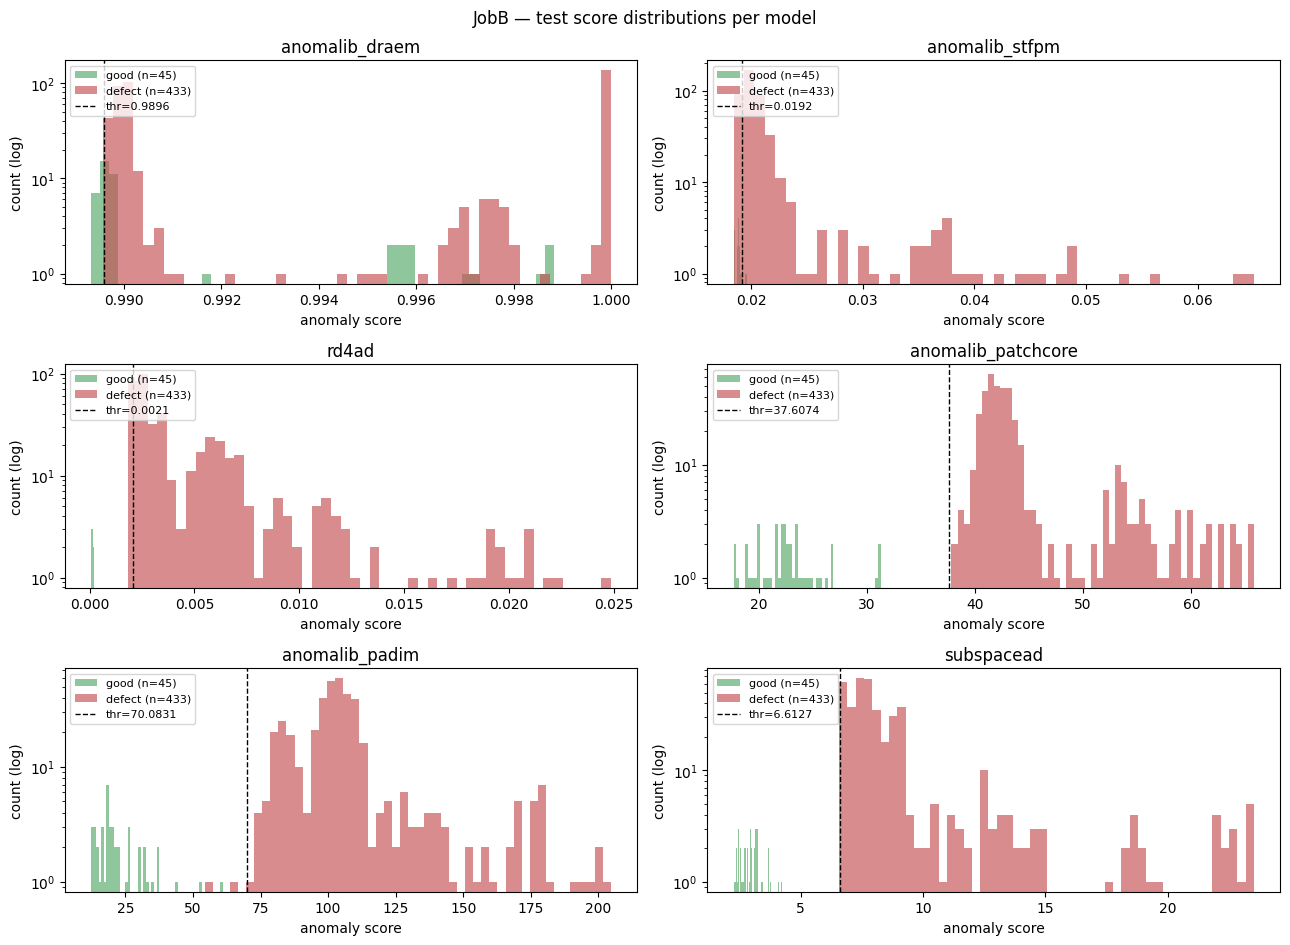

In [15]:
n = len(df)
ncols = 2
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(13, 3.2 * nrows))
axes = np.array(axes).reshape(nrows, ncols)
for ax, (_, r) in zip(axes.ravel(), df.iterrows()):
    test = load_predictions(JOBB_DIR / r["run_dir"], r["model"])
    if test.empty:
        ax.set_visible(False)
        continue
    good_scores = test.loc[test["label"] == 0, "score"]
    bad_scores = test.loc[test["label"] == 1, "score"]
    bins = 50
    ax.hist(good_scores, bins=bins, alpha=0.65, label=f"good (n={len(good_scores)})", color="#55a868")
    ax.hist(bad_scores, bins=bins, alpha=0.65, label=f"defect (n={len(bad_scores)})", color="#c44e52")
    ax.axvline(r["threshold_used"], color="black", ls="--", lw=1, label=f"thr={r['threshold_used']:.4f}")
    ax.set_yscale("log")
    ax.set_title(f"{r['model']}")
    ax.set_xlabel("anomaly score")
    ax.set_ylabel("count (log)")
    ax.legend(fontsize=8, loc="upper left")
for ax in axes.ravel()[len(df):]:
    ax.set_visible(False)
fig.suptitle("JobB — test score distributions per model", fontsize=12)
fig.tight_layout()
plt.show()

## §5 Confusion matrices

Recomputed from `predictions_*.json` so the headline F1 in §1 can be audited end-to-end.

In [16]:
def confusion(test_df: pd.DataFrame) -> pd.DataFrame:
    cm = pd.crosstab(
        test_df["label"].map({0: "good", 1: "defect"}),
        test_df["pred_is_anomaly"].map({0: "pred_good", 1: "pred_defect"}),
        rownames=["actual"], colnames=["predicted"], dropna=False,
    )
    for col in ["pred_good", "pred_defect"]:
        if col not in cm.columns:
            cm[col] = 0
    for row in ["good", "defect"]:
        if row not in cm.index:
            cm.loc[row] = 0
    return cm.loc[["good", "defect"], ["pred_good", "pred_defect"]]

for _, r in df.iterrows():
    test = load_predictions(JOBB_DIR / r["run_dir"], r["model"])
    if test.empty:
        continue
    cm = confusion(test)
    tp = cm.loc["defect", "pred_defect"]
    fp = cm.loc["good", "pred_defect"]
    fn = cm.loc["defect", "pred_good"]
    tn = cm.loc["good", "pred_good"]
    prec = tp / (tp + fp) if (tp + fp) else float("nan")
    rec = tp / (tp + fn) if (tp + fn) else float("nan")
    print(f"=== {r['model']} ===")
    print(cm.to_string())
    print(f"recomputed precision={prec:.4f} recall={rec:.4f} (reported precision={r['precision']:.4f} recall={r['recall']:.4f})")
    print()

=== anomalib_draem ===
predicted  pred_good  pred_defect
actual                           
good              16           29
defect             2          431
recomputed precision=0.9370 recall=0.9954 (reported precision=0.9370 recall=0.9954)

=== anomalib_stfpm ===
predicted  pred_good  pred_defect
actual                           
good              33           12
defect            63          370
recomputed precision=0.9686 recall=0.8545 (reported precision=0.9686 recall=0.8545)

=== rd4ad ===
predicted  pred_good  pred_defect
actual                           
good              45            0
defect            15          418
recomputed precision=1.0000 recall=0.9654 (reported precision=1.0000 recall=0.9654)

=== anomalib_patchcore ===
predicted  pred_good  pred_defect
actual                           
good              45            0
defect             0          433
recomputed precision=1.0000 recall=1.0000 (reported precision=1.0000 recall=1.0000)

=== anomalib_padim ===
predic

## §6 JobB vs JobA reference

Reuse the pre-computed comparison TSV (`_analysis/compare_jobB_vs_jobA.tsv`) — it already has the
per-model JobA mean ± std baselines next to the JobB single number.

Only `patchcore`, `padim`, and `subspacead` are present in that TSV because those are the three
models JobA evaluated across all MVTec / Real-IAD categories. The new JobB-only models (`draem`,
`stfpm`, `rd4ad`) need to be paired with their JobA counterparts manually.

In [17]:
tsv_path = ANALYSIS_DIR / "compare_jobB_vs_jobA.tsv"
if tsv_path.is_file():
    cmp_df = pd.read_csv(tsv_path, sep="\t")
    display_cols = ["model", "auroc_jobA_mean", "auroc_jobA_std", "auroc_jobB", "auroc_diff",
                    "f1_jobA_mean", "f1_jobB", "f1_diff", "recall_jobA_mean", "recall_jobB", "recall_diff",
                    "ms_per_image_jobA_mean", "ms_per_image_jobB", "ms_per_image_diff"]
    display_cols = [c for c in display_cols if c in cmp_df.columns]
    display(cmp_df[display_cols].round(3))
else:
    print(f"(missing {tsv_path} — skip)")

,model,auroc_jobA_mean,auroc_jobA_std,auroc_jobB,auroc_diff,f1_jobA_mean,f1_jobB,f1_diff,recall_jobA_mean,recall_jobB,recall_diff,ms_per_image_jobA_mean,ms_per_image_jobB,ms_per_image_diff
0,anomalib_patchcore,0.870,0.088,1.0,0.130,0.905,1.000,0.095,0.884,1.000,0.116,113.576,334.235,220.659
1,anomalib_padim,0.902,0.075,1.0,0.098,0.929,0.998,0.069,0.913,0.995,0.082,10.213,20.226,10.014
2,subspacead,0.862,0.074,1.0,0.138,0.881,0.999,0.118,0.843,0.998,0.155,103.330,374.456,271.126


In [18]:
# Bonus: pair the JobB-only models against their JobA per-category mean.
extra_models = ["anomalib_draem", "anomalib_stfpm", "rd4ad"]
extra_rows = []
if JOBA_DIR.is_dir():
    for run_dir in sorted(p for p in JOBA_DIR.iterdir() if p.is_dir() and not p.name.startswith("_")):
        sp = run_dir / "benchmark_summary.json"
        if not sp.is_file():
            continue
        b = json.loads(sp.read_text())
        for m in b.get("models", []):
            if m["model"] in extra_models:
                extra_rows.append({
                    "jobA_run": run_dir.name,
                    "model": m["model"],
                    "auroc": m.get("auroc"),
                    "f1": m.get("f1"),
                    "recall": m.get("recall"),
                    "ms_per_image": m.get("ms_per_image"),
                    "fit_seconds": m.get("fit_seconds"),
                })
if extra_rows:
    extra_df = pd.DataFrame(extra_rows)
    summary = extra_df.groupby("model")[["auroc", "f1", "recall", "ms_per_image", "fit_seconds"]].agg(["mean", "std", "count"]).round(3)
    print("=== JobA aggregate for JobB-only models ===")
    display(summary)
    print("\n=== JobB single-shot numbers for the same models ===")
    display(df[df["model"].isin(extra_models)][["model", "auroc", "f1", "recall", "ms_per_image", "fit_seconds"]].round(3))
else:
    print("(no JobA runs covering draem/stfpm/rd4ad found)")

=== JobA aggregate for JobB-only models ===


auroc                  f1             recall               \
                 mean    std count   mean   std count   mean    std count   
model                                                                       
anomalib_draem  0.820  0.246     2  0.915  0.10     2  0.914  0.094     2   
anomalib_stfpm  0.669  0.102    13  0.881  0.04    13  0.908  0.085    13   
rd4ad           0.921    NaN     1  0.750   NaN     1  0.602    NaN     1   

               ms_per_image              fit_seconds                 
                       mean    std count        mean      std count  
model                                                                
anomalib_draem       18.052  0.079     2    3267.497   23.085     2  
anomalib_stfpm       10.121  2.946    13     603.719  153.866    13  
rd4ad                10.567    NaN     1     850.673      NaN     1


=== JobB single-shot numbers for the same models ===


,model,auroc,f1,recall,ms_per_image,fit_seconds
0,anomalib_draem,0.802,0.965,0.995,37.484,2861.028
1,anomalib_stfpm,0.892,0.908,0.855,13.997,446.404
2,rd4ad,1.000,0.982,0.965,25.420,1987.715


## §7 Engineering suggestions — what to look at next

Framed for the thesis goal (real-time visual defect detection that holds up on a single industrial
dataset). These are the questions the data above cannot fully answer on its own — flagging them so
the next iteration knows where to dig.

1. **Saturated metrics need a second test set.** Any model showing `auroc == 1.0` and `f1 ≥ 0.99`
   on a single 478-image test split should be retested against a *different* split (different
   `seed`, or a held-out batch from a later production day). This rules out the case where the
   train / test split happens to put all hard images on one side. The current `seed=42` is fixed —
   running with `seed=7, 17, 123` and reporting mean ± std would convert these single-shot numbers
   into something the thesis can defend.

2. **Threshold position is the silent failure mode.** §3.3 shows the calibrated threshold relative
   to the test score range. If a model's threshold sits below `min(test_score)` *and* above
   `min(val_score)` it just means "label everything as anomaly," which inflates recall to ≈1 while
   precision becomes whatever the prevalence allows. Treat any model where
   `frac_test_above_thr ∈ {<0.05, >0.95}` as effectively un-calibrated and rerun with
   `threshold_mode=val_quantile` for comparison.

3. **Generalization gap matters more than headline F1.** The `*_gap` columns in §1 are the ones to
   put in the thesis. A model with `val_f1=0.95` and `f1=0.96` is more trustworthy than one with
   `val_f1=0.90` and `f1=1.00`, even though the latter looks better on paper.

4. **Per-defect recall is where the deceuninck story gets interesting.** Support is heavily skewed
   (Scratch=353 vs Black-spots=16). A model that scores `recall=1.0` on Black-spots but `0.83` on
   Scratch is mostly being judged on Scratch. Plot recall against support and only celebrate models
   that hold the line on the high-support classes.

5. **Latency is reported as `ms_per_image` averaged over the full test set, single-image batch.**
   For a real-time deployment the relevant number is `p95_latency_ms` from `live_status_*.json`,
   not the mean — add it to the comparison table when the SLA discussion comes up.

6. **Fit-time delta vs JobA is the throughput story.** §6's `extra_models` block compares
   `fit_seconds` JobA-mean against JobB. If JobB ran ~3× faster than the JobA average for the same
   model, that is either (a) a smaller training set on Deceuninck (`train_samples=161` vs 200–500
   typical for Real-IAD), or (b) the run hit an early-stopping path. Worth checking the
   per-epoch loss curve before writing it up as a speedup.

7. **Cross-check with `live_status_*.json`.** The `fail_count` field is the count of frames the
   live consumer flagged. If `fail_count / frames_seen` differs from `1 - precision * recall / f1`
   it usually means the live pipeline applied a different threshold or skipped frames — a
   discrepancy here would invalidate any latency claim made from the same run.

8. **Persist a `manifest.csv`.** Right now run discovery is by directory name + timestamp. A flat
   manifest (`run_id, model, dataset, threshold_mode, seed, git_sha`) would make every future
   notebook one `pd.read_csv` away from the answer instead of re-walking the filesystem.